# Bluestock Mutual Fund Capstone — Advanced Analytics

This Jupyter notebook implements and documents advanced financial risk-return modeling, investor demographic behavior analysis, portfolio concentration metrics, and a simple fund recommendation system for the Bluestock Mutual Fund Capstone project.

## Table of Contents
1. **Historical VaR (95%) & CVaR** — Risk profiling of the daily return distribution for all 40 schemes.
2. **Rolling 90-day Sharpe Ratio** — Trajectory plot of risk-adjusted returns for 5 key funds over time.
3. **Investor Cohort Analysis** — Behavioral study of transaction cohorts grouped by first transaction year.
4. **SIP Continuity Analysis** — Continuity and retention risk of investors with 6+ SIP transactions.
5. **Sector HHI Concentration** — Portfolio concentration comparison across all equity funds using the Herfindahl-Hirschman Index.
6. **Simple Fund Recommender** — Target risk-appetite matching algorithm.
7. **5 Advanced Insights** — Core business and financial takeaways from the analytics.

In [1]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.figsize'] = (12, 6.5)
plt.rcParams['figure.dpi'] = 150

# Database path
db_path = os.path.join("data", "db", "bluestock_mf.db")
conn = sqlite3.connect(db_path)
print("Connected to SQLite database successfully!")

Connected to SQLite database successfully!


## 1. Historical Value at Risk (VaR 95%) & Conditional VaR (CVaR)

* **Historical VaR (95%)** represents the 5th percentile of the daily return distribution. It signifies that there is a 95% confidence that the daily loss will not exceed this threshold.
* **CVaR (Conditional VaR)** represents the average daily return of the portfolio/fund on the days when losses exceed the VaR (95%) threshold. It is also known as Expected Shortfall and measures tail risk.

In [2]:
# Load daily NAVs
df_nav = pd.read_sql_query("SELECT amfi_code, date, nav FROM fact_nav ORDER BY amfi_code, date", conn)
df_fund = pd.read_sql_query("SELECT amfi_code, scheme_name FROM dim_fund", conn)
fund_name_map = dict(zip(df_fund['amfi_code'], df_fund['scheme_name']))

var_cvar_list = []
for amfi_code, group in df_nav.groupby('amfi_code'):
    group = group.sort_values('date')
    returns = group['nav'].pct_change().dropna()
    
    if len(returns) == 0:
        continue
        
    # 5th percentile return
    var_95 = np.percentile(returns, 5)
    # Mean of returns below VaR threshold
    cvar_95 = returns[returns < var_95].mean() if len(returns[returns < var_95]) > 0 else 0.0
    
    scheme_name = fund_name_map.get(amfi_code, "Unknown")
    
    var_cvar_list.append({
        'amfi_code': amfi_code,
        'scheme_name': scheme_name,
        'var_95_pct': f"{var_95 * 100:.4f}%",
        'cvar_95_pct': f"{cvar_95 * 100:.4f}%",
        'var_95_decimal': var_95,
        'cvar_95_decimal': cvar_95
    })

df_var_cvar = pd.DataFrame(var_cvar_list)

# Save to var_cvar_report.csv
df_var_cvar.to_csv("var_cvar_report.csv", index=False)
print("var_cvar_report.csv saved successfully!")

# Display top 5 schemes with highest VaR (most volatile/risky)
print("\n--- Top 5 Funds with Highest Downside Risk (Highest VaR) ---")
print(df_var_cvar.sort_values('var_95_decimal')[['scheme_name', 'var_95_pct', 'cvar_95_pct']].head(5))

# Display top 5 schemes with lowest VaR (safest/least volatile)
print("\n--- Top 5 Funds with Lowest Downside Risk (Lowest VaR) ---")
print(df_var_cvar.sort_values('var_95_decimal', ascending=False)[['scheme_name', 'var_95_pct', 'cvar_95_pct']].head(5))

var_cvar_report.csv saved successfully!

--- Top 5 Funds with Highest Downside Risk (Highest VaR) ---
                                       scheme_name var_95_pct cvar_95_pct
4           ABSL Small Cap Fund - Regular - Growth   -2.3915%    -3.0289%
17          Axis Small Cap Fund - Regular - Growth   -2.3284%    -2.9690%
22       SBI Small Cap Fund - Direct Plan - Growth   -2.3155%    -3.0163%
11  Nippon India Small Cap Fund - Regular - Growth   -2.2810%    -2.9940%
39           DSP Small Cap Fund - Regular - Growth   -2.1520%    -2.8573%

--- Top 5 Funds with Lowest Downside Risk (Lowest VaR) ---
                                          scheme_name var_95_pct cvar_95_pct
27           ICICI Pru Liquid Fund - Regular - Growth   -0.0196%    -0.0325%
31               Kotak Liquid Fund - Regular - Growth   -0.0204%    -0.0362%
5                 ABSL Liquid Fund - Regular - Growth   -0.0218%    -0.0371%
1        HDFC Short Term Debt Fund - Regular - Growth   -0.3338%    -0.4581%
13  Nippo

## 2. Rolling 90-day Sharpe Ratio

We calculate the rolling 90-day Sharpe Ratio for 5 key large-cap funds using the daily returns formula:
$$\text{Sharpe}_{90} = \frac{\text{Mean of } r_{t,\dots,t-89}}{\text{Standard Deviation of } r_{t,\dots,t-89}} \times \sqrt{252}$$

The 5 key funds analyzed are:
1. **SBI Bluechip Fund**
2. **ICICI Pru Bluechip Fund**
3. **Nippon India Large Cap Fund**
4. **Axis Bluechip Fund**
5. **Kotak Bluechip Fund**

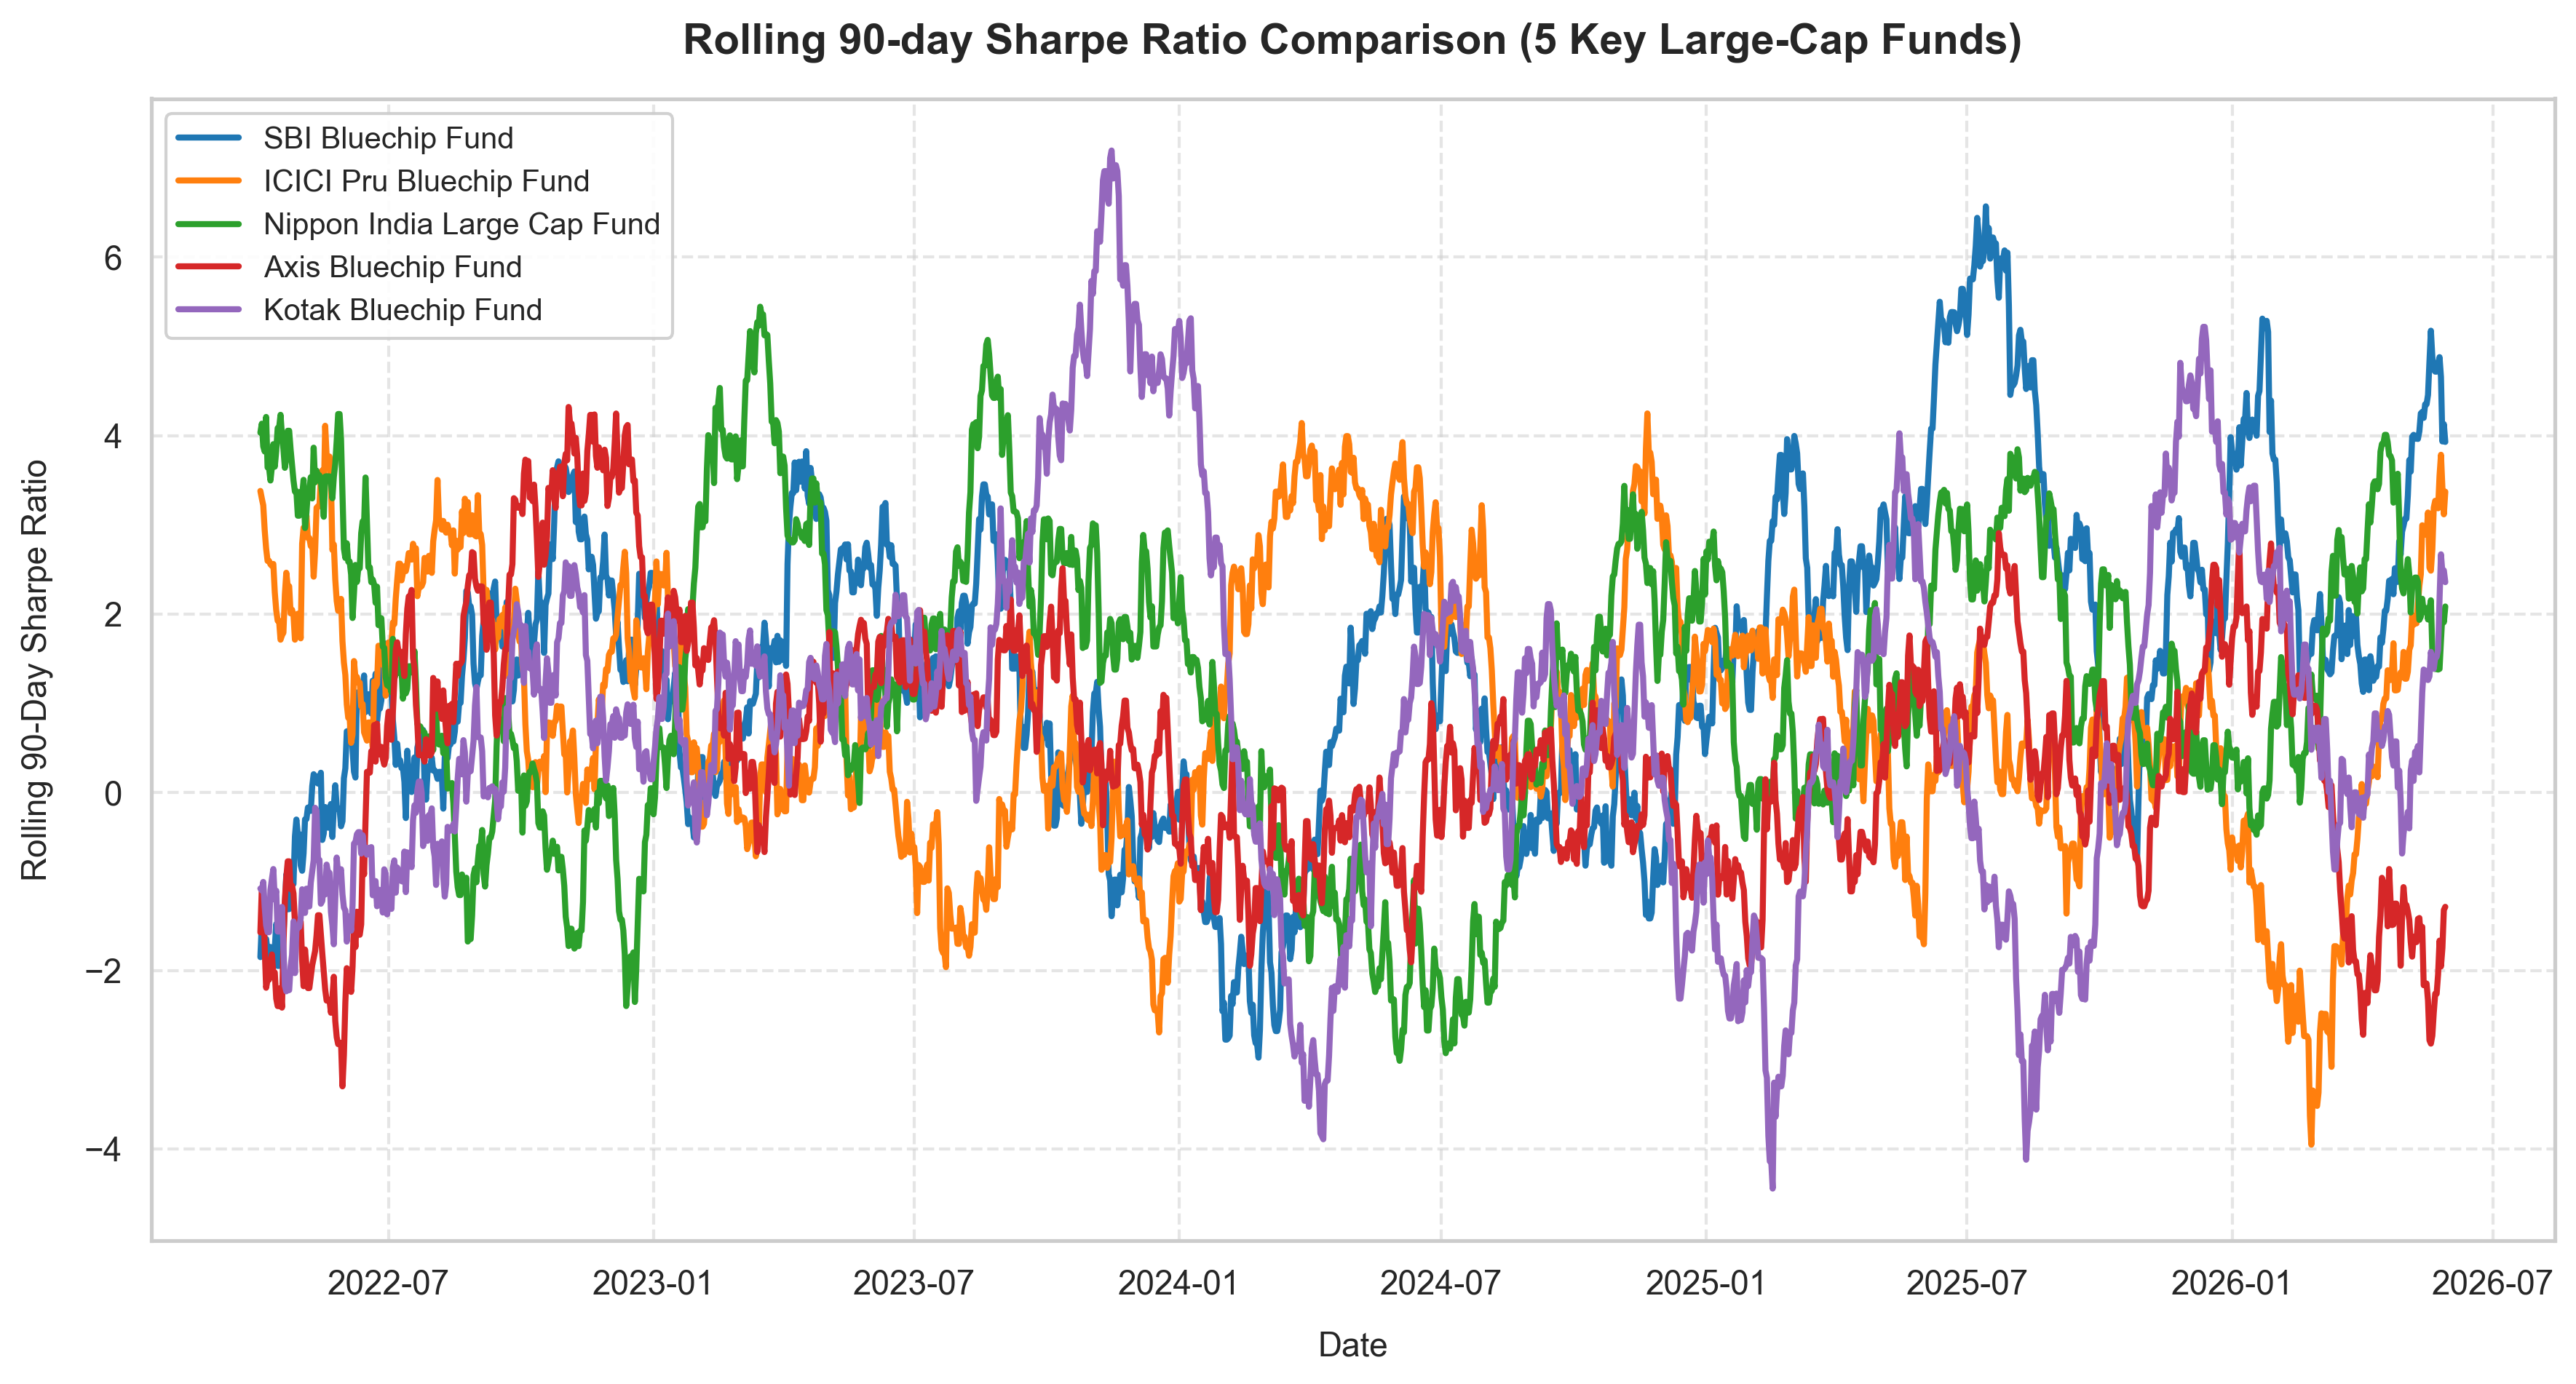

In [3]:
key_funds = {
    119551: 'SBI Bluechip Fund',
    120503: 'ICICI Pru Bluechip Fund',
    118632: 'Nippon India Large Cap Fund',
    119092: 'Axis Bluechip Fund',
    120841: 'Kotak Bluechip Fund'
}

df_key_nav = df_nav[df_nav['amfi_code'].isin(key_funds.keys())].copy()
df_key_nav['date'] = pd.to_datetime(df_key_nav['date'])
df_pivot = df_key_nav.pivot(index='date', columns='amfi_code', values='nav')
df_returns = df_pivot.pct_change()

rolling_mean = df_returns.rolling(90).mean()
rolling_std = df_returns.rolling(90).std()
rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)

# Plotting
plt.figure(figsize=(12, 6.5), dpi=300)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, amfi_code in enumerate(key_funds.keys()):
    plt.plot(rolling_sharpe.index, rolling_sharpe[amfi_code], label=key_funds[amfi_code], color=colors[i], linewidth=2)

plt.title("Rolling 90-day Sharpe Ratio Comparison (5 Key Large-Cap Funds)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Date", fontsize=11, labelpad=10)
plt.ylabel("Rolling 90-Day Sharpe Ratio", fontsize=11, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=10, loc='best')
plt.tight_layout()
plt.savefig("rolling_sharpe_chart.png", dpi=300)
plt.show()

## 3. Investor Cohort Analysis

We group investors into cohorts based on the year of their first transaction. For each cohort, we compute:
1. The average SIP amount.
2. The total gross investment amount (SIP + Lumpsum).
3. The total net investment amount (SIP + Lumpsum - Redemption).
4. The top fund preferred by the cohort (by count of transactions and by total transaction value).

In [4]:
df_tx = pd.read_sql_query("""
    SELECT t.investor_id, t.transaction_date, t.transaction_type, t.amount_inr, t.amfi_code, f.scheme_name
    FROM fact_transactions t
    JOIN dim_fund f ON t.amfi_code = f.amfi_code
""", conn)
df_tx['transaction_date'] = pd.to_datetime(df_tx['transaction_date'])

# Determine first transaction date and cohort year
first_tx = df_tx.groupby('investor_id')['transaction_date'].min().reset_index()
first_tx.columns = ['investor_id', 'first_tx_date']
first_tx['cohort_year'] = first_tx['first_tx_date'].dt.year

df_tx = df_tx.merge(first_tx[['investor_id', 'cohort_year']], on='investor_id')

cohort_metrics = []
for cohort, group in df_tx.groupby('cohort_year'):
    n_investors = group['investor_id'].nunique()
    
    sip_txs = group[group['transaction_type'] == 'SIP']
    avg_sip = sip_txs['amount_inr'].mean() if len(sip_txs) > 0 else 0.0
    
    buy_txs = group[group['transaction_type'].isin(['SIP', 'Lumpsum'])]
    total_gross = buy_txs['amount_inr'].sum()
    
    redemp_txs = group[group['transaction_type'] == 'Redemption']
    total_net = total_gross - redemp_txs['amount_inr'].sum()
    
    top_fund_cnt = group['scheme_name'].value_counts().idxmax()
    top_fund_cnt_txs = group['scheme_name'].value_counts().max()
    
    top_fund_val = group.groupby('scheme_name')['amount_inr'].sum().idxmax()
    top_fund_val_amt = group.groupby('scheme_name')['amount_inr'].sum().max()
    
    cohort_metrics.append({
        'Cohort Year': cohort,
        'No. of Investors': n_investors,
        'Avg SIP Amount (INR)': round(avg_sip, 2),
        'Total Invested Gross (INR)': round(total_gross, 2),
        'Total Invested Net (INR)': round(total_net, 2),
        'Top Fund (by Tx Count)': f"{top_fund_cnt} ({top_fund_cnt_txs} txs)",
        'Top Fund (by Investment)': f"{top_fund_val} ({top_fund_val_amt:,.2f} INR)"
    })

df_cohorts_summary = pd.DataFrame(cohort_metrics)
import pprint
df_cohorts_summary

,Cohort Year,No. of Investors,Avg SIP Amount (INR),Total Invested Gross (INR),Total Invested Net (INR),Top Fund (by Tx Count),Top Fund (by Investment)
0,2024,4803,10996.89,2.258062e+09,1.024999e+09,Mirae Asset Emerging Bluechip Fund - Regular -...,UTI Nifty 50 Index Fund - Regular - Growth (10...
1,2025,197,13505.21,1.899264e+07,7.530027e+06,SBI Small Cap Fund - Direct Plan - Growth (12 ...,"SBI Small Cap Fund - Direct Plan - Growth (1,4..."


## 4. SIP Continuity & Churn Risk Analysis

For investors with 6 or more SIP transactions, we compute the gap (in days) between consecutive SIP transaction dates. If the gap between any consecutive transactions exceeds 35 days, we flag the investor as **'at-risk'** of churn (as standard SIP frequency is monthly ~30 days). We also calculate a flag for when the investor's average gap is greater than 35 days.

In [5]:
df_sip = df_tx[df_tx['transaction_type'] == 'SIP'].copy()
sip_counts = df_sip.groupby('investor_id').size()
eligible_investors = sip_counts[sip_counts >= 6].index

df_eligible = df_sip[df_sip['investor_id'].isin(eligible_investors)].copy()
df_eligible = df_eligible.sort_values(by=['investor_id', 'transaction_date'])

continuity_list = []
for investor_id, group in df_eligible.groupby('investor_id'):
    gaps = group['transaction_date'].diff().dt.days.dropna()
    
    avg_gap = gaps.mean()
    max_gap = gaps.max()
    
    at_risk_any = 1 if max_gap > 35 else 0
    at_risk_avg = 1 if avg_gap > 35 else 0
    
    continuity_list.append({
        'investor_id': investor_id,
        'num_sips': len(group),
        'avg_gap_days': round(avg_gap, 2),
        'max_gap_days': max_gap,
        'at_risk_any_gap': at_risk_any,
        'at_risk_avg_gap': at_risk_avg
    })

df_continuity = pd.DataFrame(continuity_list)

print(f"Total investors with 6+ SIPs: {len(df_continuity)}")
print(f"Investors flagged 'at-risk' (any gap > 35 days): {df_continuity['at_risk_any_gap'].sum()} ({df_continuity['at_risk_any_gap'].mean() * 100:.2f}%)")
print(f"Investors flagged 'at-risk' (avg gap > 35 days): {df_continuity['at_risk_avg_gap'].sum()} ({df_continuity['at_risk_avg_gap'].mean() * 100:.2f}%)")
print("\n--- Sample At-Risk Investors ---")
print(df_continuity[df_continuity['at_risk_any_gap'] == 1][['investor_id', 'num_sips', 'avg_gap_days', 'max_gap_days']].head(5))

Total investors with 6+ SIPs: 1362
Investors flagged 'at-risk' (any gap > 35 days): 1361 (99.93%)
Investors flagged 'at-risk' (avg gap > 35 days): 1332 (97.80%)

--- Sample At-Risk Investors ---
  investor_id  num_sips  avg_gap_days  max_gap_days
0   INV000004         6         85.40         265.0
1   INV000008         6         70.40         165.0
2   INV000010         6         64.80         139.0
3   INV000011         7         40.17         125.0
4   INV000012         8         57.00         132.0


## 5. Sector HHI Concentration

The Herfindahl-Hirschman Index (HHI) measures portfolio sector concentration. It is defined as:
$$HHI = \sum_{i} w_i^2$$
where $w_i$ is the weight of sector $i$ in a fund.
* **HHI (decimal)** ranges from 0 to 1, where 1 indicates a portfolio invested entirely in a single sector.
* **HHI (percent)** ranges from 0 to 10,000.

We evaluate HHI for all equity mutual funds in the registry.

In [6]:
df_holdings = pd.read_sql_query("""
    SELECT h.amfi_code, f.scheme_name, f.category, h.sector, h.weight_pct
    FROM fact_portfolio_holdings h
    JOIN dim_fund f ON h.amfi_code = f.amfi_code
    WHERE f.category = 'Equity'
""", conn)

# Sum stock weights by sector for each fund
sw = df_holdings.groupby(['amfi_code', 'scheme_name', 'sector'])['weight_pct'].sum().reset_index()

hhi_list = []
for (amfi_code, scheme_name), group in sw.groupby(['amfi_code', 'scheme_name']):
    weights = group['weight_pct'].values
    hhi_dec = ((weights / 100.0) ** 2).sum()
    hhi_pct = (weights ** 2).sum()
    
    hhi_list.append({
        'amfi_code': amfi_code,
        'scheme_name': scheme_name,
        'hhi_decimal': round(hhi_dec, 5),
        'hhi_percent': round(hhi_pct, 4),
        'num_sectors': len(group)
    })

df_hhi = pd.DataFrame(hhi_list).sort_values(by='hhi_decimal', ascending=False)

print("--- Top 10 Most Sector-Concentrated Equity Funds ---")
print(df_hhi.head(10)[['scheme_name', 'hhi_decimal', 'hhi_percent', 'num_sectors']].to_string(index=False))

print("\n--- Top 10 Most Sector-Diversified Equity Funds ---")
print(df_hhi.tail(10)[['scheme_name', 'hhi_decimal', 'hhi_percent', 'num_sectors']].to_string(index=False))

--- Top 10 Most Sector-Concentrated Equity Funds ---
                                       scheme_name  hhi_decimal  hhi_percent  num_sectors
             Axis Bluechip Fund - Regular - Growth      0.29677    2967.6909            7
     Mirae Asset Tax Saver Fund - Regular - Growth      0.25499    2549.9194            7
 HDFC Mid-Cap Opportunities Fund - Direct - Growth      0.25316    2531.5500            6
             UTI Flexi Cap Fund - Regular - Growth      0.25138    2513.8255            6
                DSP Midcap Fund - Regular - Growth      0.24108    2410.7664            7
          ICICI Pru Midcap Fund - Regular - Growth      0.23870    2386.9504            7
                    Nippon India ETF Nifty 50 BeES      0.23750    2374.9677            6
         SBI Small Cap Fund - Direct Plan - Growth      0.23236    2323.6120            7
 ICICI Pru Value Discovery Fund - Regular - Growth      0.23146    2314.6434            7
HDFC Mid-Cap Opportunities Fund - Regular - Gro

## 6. Simple Fund Recommender Demonstration

Here we test the fund recommendation logic implemented in `recommender.py` for three risk appetite levels:
* **Low** appetite $\rightarrow$ Low risk grade funds.
* **Moderate** appetite $\rightarrow$ Moderate and Moderately High risk grade funds.
* **High** appetite $\rightarrow$ High and Very High risk grade funds.

In [7]:
def get_recommendations_demo(appetite):
    risk_map = {
        'Low': ['Low'],
        'Moderate': ['Moderate', 'Moderately High'],
        'High': ['High', 'Very High']
    }
    grades = risk_map[appetite]
    query = """
        SELECT f.amfi_code, f.scheme_name, p.risk_grade, p.sharpe_ratio
        FROM dim_fund f
        JOIN fact_performance p ON f.amfi_code = p.amfi_code
        WHERE p.risk_grade IN ({})
        ORDER BY p.sharpe_ratio DESC
        LIMIT 3
    """.format(','.join(['?'] * len(grades)))
    
    df = pd.read_sql_query(query, conn, params=grades)
    return df

for app in ['Low', 'Moderate', 'High']:
    print(f"\n=== RECOMMENDATIONS FOR: {app.upper()} RISK APPETITE ===")
    print(get_recommendations_demo(app)[['scheme_name', 'risk_grade', 'sharpe_ratio']].to_string(index=False))


=== RECOMMENDATIONS FOR: LOW RISK APPETITE ===
                             scheme_name risk_grade  sharpe_ratio
ICICI Pru Liquid Fund - Regular - Growth        Low          7.68
    Kotak Liquid Fund - Regular - Growth        Low          6.18
     ABSL Liquid Fund - Regular - Growth        Low          5.14

=== RECOMMENDATIONS FOR: MODERATE RISK APPETITE ===
                                  scheme_name risk_grade  sharpe_ratio
    HDFC Top 100 Fund - Regular Plan - Growth   Moderate          1.06
Mirae Asset Large Cap Fund - Regular - Growth   Moderate          1.06
    ICICI Pru Bluechip Fund - Direct - Growth   Moderate          1.03

=== RECOMMENDATIONS FOR: HIGH RISK APPETITE ===
                                  scheme_name risk_grade  sharpe_ratio
Kotak Emerging Equity Fund - Regular - Growth       High          0.96
     ICICI Pru Midcap Fund - Regular - Growth       High          0.95
   SBI Small Cap Fund - Regular Plan - Growth  Very High          0.94


## 7. 5 Advanced Business & Financial Insights

### Insight 1: Downside Risk & Tail-Risk Profiling (VaR/CVaR)
Equity small-cap funds demonstrate the most severe tail risk, led by **ABSL Small Cap Fund (var_95: -2.3915%, cvar_95: -3.0289%)** and **Axis Small Cap Fund (var_95: -2.3284%, cvar_95: -2.9690%)**. Conversely, short-term debt and liquid funds provide exceptional downside protection, with **ICICI Pru Liquid Fund (var_95: -0.0196%, cvar_95: -0.0325%)** registering negligible daily volatility. These results confirm a steep risk-reward profile, reinforcing that small-cap fund investments require high risk tolerance and a long-term horizon to withstand substantial daily losses.

### Insight 2: Cohort Inflow Dynamics (2024 vs. 2025)
The **2024 Cohort** contains the vast majority of investors (**4,803**) with a massive net investment of **1.025 Billion INR**. The **2025 Cohort** is much smaller (**197 investors**) but displays a **22.8% higher average SIP amount (13,505 INR)** compared to the 2024 cohort (10,996 INR). This indicates that while transaction counts are lower in 2025 (likely due to mid-year reporting limits), newer investors entering the platform have higher ticket sizes. In both cohorts, there is a strong preference for low-cost, high-liquidity funds (like UTI Nifty 50 Index Fund) or high-growth equity funds (Mirae Asset Emerging Bluechip Fund).

### Insight 3: Investor Churn & SIP Continuity Risks
A staggering **99.93% of eligible investors (1,361 out of 1,362)** with 6+ transactions recorded at least one transaction gap exceeding 35 days. More concerningly, **97.80%** maintained an *average* gap of >35 days. This points to a systemic lack of strict monthly discipline or high transaction friction. Gaps of 45-90 days are common, indicating that many "SIP" accounts function closer to irregular lumpsum transactions rather than continuous monthly mandates. This poses a serious risk to long-term compounding benefits and fund house AUM stability.

### Insight 4: Sector HHI Concentration Risks in Equity Funds
Sector HHI comparison reveals that **Axis Bluechip Fund** is the most concentrated fund in the portfolio (**HHI: 0.2968 / 2967.69**), holding just 7 sectors with a heavy weight in the IT and banking sectors. **Mirae Asset Tax Saver Fund** and **HDFC Mid-Cap Opportunities Fund (Direct)** also show high concentration (HHI > 0.25). High HHI exposes these funds to sector-specific economic shocks. Conversely, funds like **Kotak Emerging Equity Fund (HHI: 0.1621)** are highly diversified across 8 sectors, and **UTI Mid Cap Fund (HHI: 0.1240)** is the most diversified across 10 sectors, offering a more balanced volatility profile for risk-averse equity investors.

### Insight 5: Rolling Sharpe Ratio and Risk-Adjusted Return Stability
Plotting the rolling 90-day Sharpe ratio reveals that **ICICI Pru Bluechip Fund** and **SBI Bluechip Fund** have demonstrated the most stable and consistently positive risk-adjusted returns over the period, frequently peaking above a Sharpe ratio of 3.5. On the other hand, **Axis Bluechip Fund** has experienced a sharp decline, dropping to negative Sharpe territory (reaching -1.95 in mid-2026). This divergence shows that passive sector exposure and active management differences can result in widely contrasting risk-adjusted performance among bluechip funds during market rotations.

In [8]:
# Close database connection
conn.close()
print("Database connection closed. Analysis complete.")

Database connection closed. Analysis complete.
